# Exploratory Data Analysis 

**Dataset:**

- C-MAPSS (Commercial Modular Aero-Propulsion System Simulation)
- Variant: FD004 

**Variant Details:**

- Operating conditions: 6 (Varied Altitudes/Speeds)
- Fault Modes: 2 (HPC: High-Pressure Compressor & Fan Degradation)

**Prelimnary Analysis and Notes:**

- File format: .txt
- Separate train and test set provided
- Validation strategy: 80-20 temporal split from train set
- RUL:remaining useful life needs to be calculated; it is not provided in the dataset


## Dataset path defination

In [1]:
#raw data paths

train_raw_path = "../data/raw/CMAPSSData/train_FD004.txt"
x_test_raw_path = "../data/raw/CMAPSSData/test_FD004.txt"
rul_test_raw_path = "../data/raw/CMAPSSData/RUL_FD004.txt"

#processed data paths
base_processed_path = "../data/processed/"

## Load datasets

In [2]:
from utils.DataLoading import load_cmapss_fd004, load_rul_truth

In [3]:
train_raw = load_cmapss_fd004(train_raw_path)
train_raw.head()

,unit_id,cycle,altitude,mach_number,tra,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [4]:
x_test_raw = load_cmapss_fd004(x_test_raw_path)
x_test_raw.head()

,unit_id,cycle,altitude,mach_number,tra,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,20.0072,0.7000,100.0,491.19,606.67,1481.04,1227.81,9.35,...,313.03,2387.78,8048.98,9.2229,0.02,362,2324,100.00,24.31,14.7007
1,1,2,24.9984,0.6200,60.0,462.54,536.22,1256.17,1031.48,7.05,...,163.61,2028.09,7863.46,10.8632,0.02,306,1915,84.93,14.36,8.5748
2,1,3,42.0000,0.8420,100.0,445.00,549.23,1340.13,1105.88,3.91,...,129.98,2387.95,8071.13,9.3960,0.02,328,2212,100.00,10.39,6.4365
3,1,4,42.0035,0.8402,100.0,445.00,549.19,1339.70,1107.26,3.91,...,129.48,2387.90,8078.89,9.3594,0.02,328,2212,100.00,10.56,6.2367
4,1,5,35.0079,0.8400,100.0,449.44,555.10,1353.04,1117.80,5.48,...,181.82,2387.87,8057.83,9.3030,0.02,333,2223,100.00,14.85,8.9326


In [5]:
rul_test_raw = load_rul_truth(rul_test_raw_path)
rul_test_raw.head()

,true_rul
0,22
1,39
2,107
3,75
4,149


## EDA Train set

In [6]:
train_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_id      61249 non-null  int64  
 1   cycle        61249 non-null  int64  
 2   altitude     61249 non-null  float64
 3   mach_number  61249 non-null  float64
 4   tra          61249 non-null  float64
 5   T2           61249 non-null  float64
 6   T24          61249 non-null  float64
 7   T30          61249 non-null  float64
 8   T50          61249 non-null  float64
 9   P2           61249 non-null  float64
 10  P15          61249 non-null  float64
 11  P30          61249 non-null  float64
 12  Nf           61249 non-null  float64
 13  Nc           61249 non-null  float64
 14  epr          61249 non-null  float64
 15  Ps30         61249 non-null  float64
 16  phi          61249 non-null  float64
 17  NRf          61249 non-null  float64
 18  NRc          61249 non-null  float64
 19  BPR          61

In [7]:
train_raw.describe()

,unit_id,cycle,altitude,mach_number,tra,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
count,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,...,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000
mean,124.325181,134.311417,23.999823,0.571347,94.031576,472.882435,579.420056,1417.896600,1201.915359,8.031626,...,266.735665,2334.427590,8067.811812,9.285604,0.023252,347.760029,2228.613283,97.751396,20.864333,12.518995
std,71.995350,89.783389,14.780722,0.310703,14.251954,26.436832,37.342647,106.167598,119.327591,3.622872,...,138.479109,128.197859,85.670543,0.750374,0.004685,27.808283,145.472491,5.369424,9.936396,5.962697
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.480000,1242.670000,1024.420000,3.910000,...,128.310000,2027.570000,7845.780000,8.175700,0.020000,302.000000,1915.000000,84.930000,10.160000,6.084300
25%,60.000000,62.000000,10.004600,0.250700,100.000000,445.000000,549.330000,1350.550000,1119.490000,3.910000,...,134.520000,2387.910000,8062.630000,8.648000,0.020000,330.000000,2212.000000,100.000000,10.940000,6.566100
50%,126.000000,123.000000,25.001400,0.700000,100.000000,462.540000,555.740000,1367.680000,1136.920000,7.050000,...,183.450000,2388.060000,8083.810000,9.255600,0.020000,334.000000,2223.000000,100.000000,14.930000,8.960100
75%,185.000000,191.000000,41.998100,0.840000,100.000000,491.190000,607.070000,1497.420000,1302.620000,10.520000,...,371.400000,2388.170000,8128.350000,9.365800,0.030000,368.000000,2324.000000,100.000000,28.560000,17.135500
max,249.000000,543.000000,42.008000,0.842000,100.000000,518.670000,644.420000,1613.000000,1440.770000,14.620000,...,537.490000,2390.490000,8261.650000,11.066300,0.030000,399.000000,2388.000000,100.000000,39.890000,23.885200


In [8]:
print(f"Number of unique unit IDs: {len(train_raw['unit_id'].unique())}")

Number of unique unit IDs: 249


### 1. Engine datapoints & cycles analysis

In [9]:
import utils.ExploratoryDataAnalysis as eda
_ = eda.analyze_engines(train_raw, setType="Train")

--- FD004 Train Set Analysis ---
Total Number of Engines: 249
Total Datapoints (Rows): 61249
Average Cycles per Engine: 245.98
Shortest Engine History: 128 cycles
Longest Engine History: 543 cycles
--------------------------------


In [10]:
df = train_raw[train_raw["unit_id"] ==1]
df

,unit_id,cycle,altitude,mach_number,tra,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,1,317,0.0014,0.0014,100.0,518.67,643.45,1599.21,1416.74,14.62,...,534.10,2388.47,8184.95,8.2760,0.03,396,2388,100.00,39.58,23.6562
317,1,318,10.0046,0.2500,100.0,489.05,605.56,1509.31,1324.42,10.52,...,380.60,2388.74,8179.79,8.4656,0.03,374,2319,100.00,28.77,17.4422
318,1,319,10.0009,0.2520,100.0,489.05,605.29,1512.36,1317.11,10.52,...,380.60,2388.81,8177.70,8.4545,0.03,373,2319,100.00,28.87,17.4126
319,1,320,20.0060,0.7002,100.0,491.19,607.24,1496.88,1266.21,9.35,...,323.53,2388.87,8108.60,9.0019,0.03,368,2324,100.00,24.90,15.0215


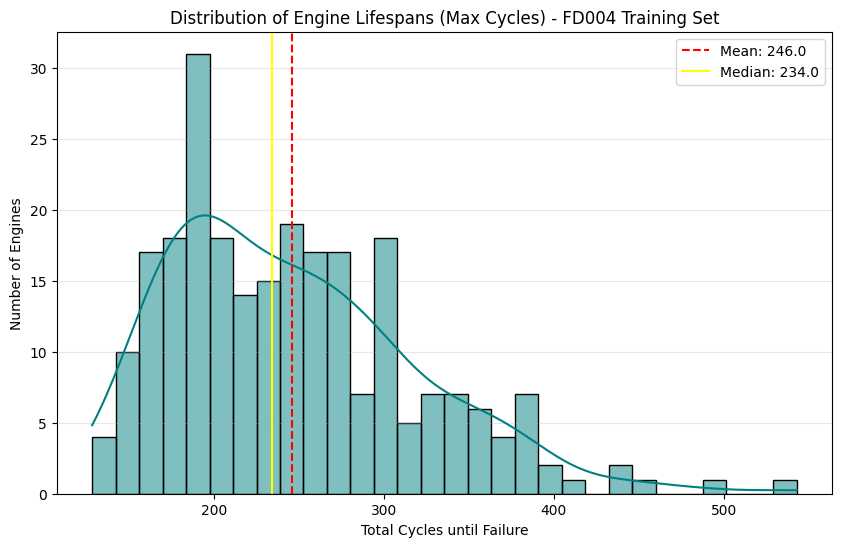

In [11]:
eda.plot_max_cycle_dist(train_raw)

### 2. Operating condition/regime analysis

--- Datapoints per Operating Regime ---
op_regime
0     9238
1     4686
2     4538
3     9139
4     9091
5    24557
Name: count, dtype: int64

Average regimes visited per engine: 6.00
Min regimes visited by an engine: 6
Max regimes visited by an engine: 6


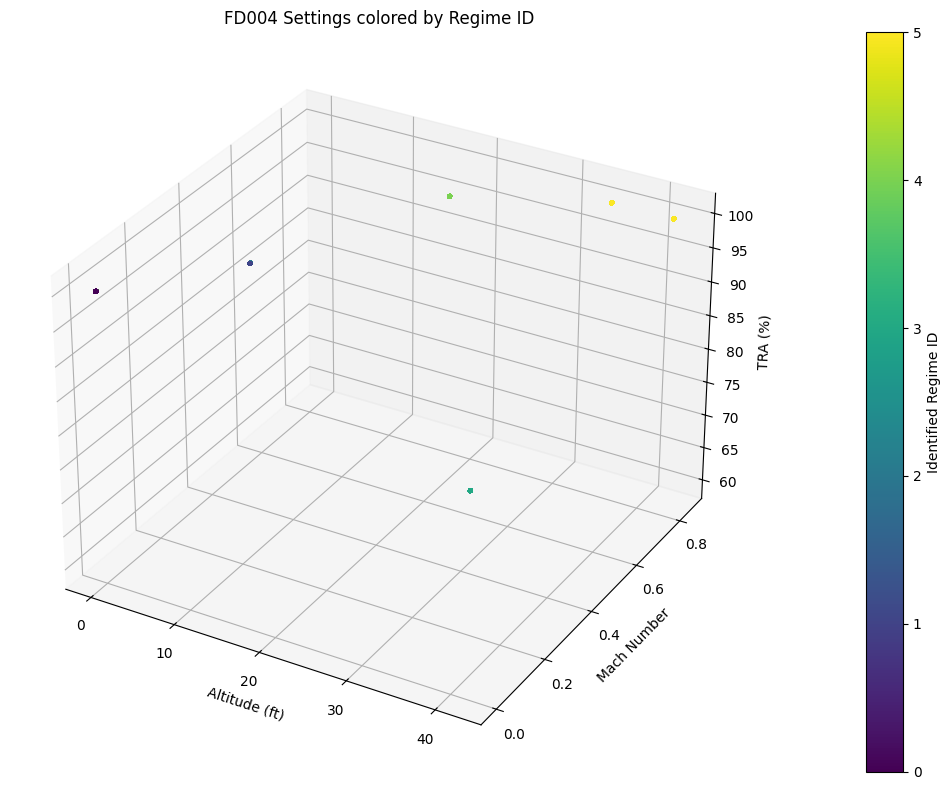

In [12]:
_ = eda.analyze_regime_clusters(train_raw)

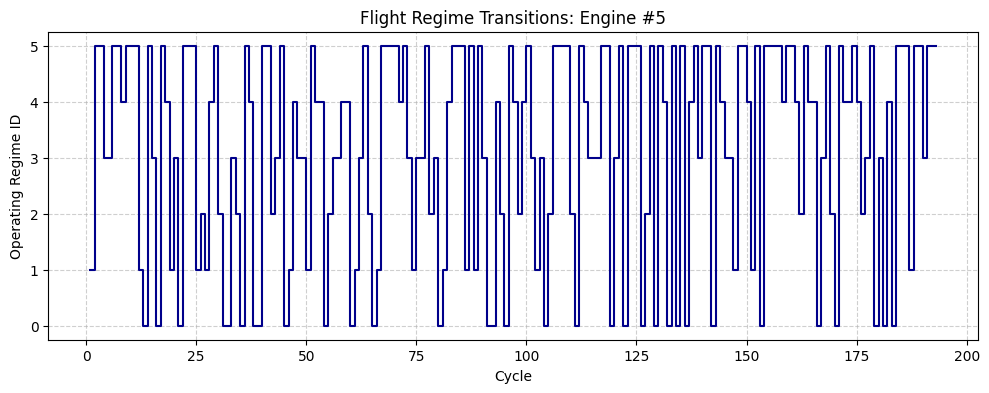

In [13]:
eda.plot_engine_step_regimes(train_raw, unit_id=5)

### 3. Identifying global flat sensors

In [14]:
_ = eda.identify_global_flat_sensors(train_raw)

--- Sensor Variance Profile (Sorted) ---
farB       | StdDev:     0.004685 
epr        | StdDev:     0.127681 
BPR        | StdDev:     0.750374 
Ps30       | StdDev:     3.243492 
P2         | StdDev:     3.622872 
PCNfR_dmd  | StdDev:     5.369424 
P15        | StdDev:     5.444017 
W32        | StdDev:     5.962697 
W31        | StdDev:     9.936396 
T2         | StdDev:    26.436832 
htBleed    | StdDev:    27.808283 
T24        | StdDev:    37.342647 
NRc        | StdDev:    85.670543 
T30        | StdDev:   106.167598 
T50        | StdDev:   119.327591 
NRf        | StdDev:   128.197859 
phi        | StdDev:   138.479109 
Nf         | StdDev:   145.348243 
Nf_dmd     | StdDev:   145.472491 
P30        | StdDev:   146.880210 
Nc         | StdDev:   336.927547 
----------------------------------------
Total Flat Sensors Found: 0
